In [2]:
# ============================================================
# Malware Detection — Imported Liabraries
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner Kaggle outputs
warnings.filterwarnings('ignore')

In [3]:
# — 1. Load Dataset ——————————————————————————
# Notice the specific file name added to the end of the path
dataset_path = '/kaggle/input/datasets/kazigolamsazidhasan/microsoft-malware-dataset/data.csv' 

try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"File not found. Please double-check the path: {dataset_path}")

Dataset loaded successfully!


In [5]:
# ── 2. Prepare Features (X) and Target (y) ──────────────────

# 1. Separate features and target 
# Note: If your dataset's target column is not named 'Class', change 'Class' to your target column name (e.g., 'HasDetections')
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Keep only numeric columns (drops text/ID columns that will cause errors)
X = X.select_dtypes(include=[np.number])

# 3. Fill missing values with the median
X = X.fillna(X.median(numeric_only=True))

print("X and y defined successfully!")
print(f"Dataset shape: {X.shape}")

X and y defined successfully!
Dataset shape: (10868, 68)


In [6]:
# ── 3. Feature Selection ─────────────────────────────────────
print(f"Original feature count: {X.shape[1]}")

# Variance threshold (Removes features with very low variance)
vt = VarianceThreshold(threshold=0.001)
X_reduced = vt.fit_transform(X)
X = pd.DataFrame(X_reduced)

print(f"Feature count after VarianceThreshold: {X.shape[1]}")

# DYNAMIC FIX: Choose the top 30 features (since you have 68 total)
features_to_select = min(30, X.shape[1])

# RFE with Random Forest estimator
rf_rfe = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
# Reduced step size to 10 for better precision with a smaller feature set
rfe = RFE(estimator=rf_rfe, n_features_to_select=features_to_select, step=10)
X = rfe.fit_transform(X, y)

print(f"Feature count after RFE: {X.shape[1]}")

Original feature count: 68
Feature count after VarianceThreshold: 68
Feature count after RFE: 30


In [7]:
# ── 4. Normalization ─────────────────────────────────────────
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# ── 5. Train/Test Split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 7607
Testing set size: 3261


In [8]:
# ── 6. SMOTE (applied to training set only) ──────────────────
print("Applying SMOTE to training data...")
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE Complete. Class distribution before and after:")
print("Before:\n", y_train.value_counts())
print("After:\n", y_train_sm.value_counts())

Applying SMOTE to training data...
SMOTE Complete. Class distribution before and after:
Before:
 Class
3    2059
2    1734
1    1079
8     860
9     709
6     526
4     332
7     279
5      29
Name: count, dtype: int64
After:
 Class
2    2059
3    2059
6    2059
1    2059
8    2059
4    2059
7    2059
9    2059
5    2059
Name: count, dtype: int64


In [9]:
# ── 7. Model Training ────────────────────────────────────────
models = {
    'Decision Tree': DecisionTreeClassifier(
        criterion='gini', max_depth=15,
        min_samples_split=5, min_samples_leaf=2, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_features='sqrt',
        max_depth=None, random_state=42, n_jobs=-1),
    'Naive Bayes': GaussianNB(var_smoothing=1e-9)
}

results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_sm, y_train_sm)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Handle probability predictions for ROC-AUC
    # Note: If this is a binary classification, roc_auc_score expects the probability of the positive class only
    y_proba = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    # Assuming multiclass setup based on your original 'ovr' argument
    try:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        # Fallback if it's actually binary classification
        auc = roc_auc_score(y_test, y_proba[:, 1])

    # Fixed the cut-off syntax error here
    results[name] = {
        'accuracy': acc, 
        'auc': auc, 
        'report': classification_report(y_test, y_pred)
    }
    
    # Print results
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")
    print(results[name]['report'])


Decision Tree
Accuracy: 0.9739 | ROC-AUC: 0.9667
              precision    recall  f1-score   support

           1       0.96      0.94      0.95       462
           2       0.99      0.99      0.99       744
           3       1.00      1.00      1.00       883
           4       0.95      0.97      0.96       143
           5       0.89      0.62      0.73        13
           6       0.93      0.95      0.94       225
           7       0.95      0.99      0.97       119
           8       0.95      0.95      0.95       368
           9       0.97      0.98      0.98       304

    accuracy                           0.97      3261
   macro avg       0.95      0.93      0.94      3261
weighted avg       0.97      0.97      0.97      3261


Random Forest
Accuracy: 0.9905 | ROC-AUC: 0.9996
              precision    recall  f1-score   support

           1       0.98      0.99      0.98       462
           2       1.00      0.99      1.00       744
           3       1.00      1.0

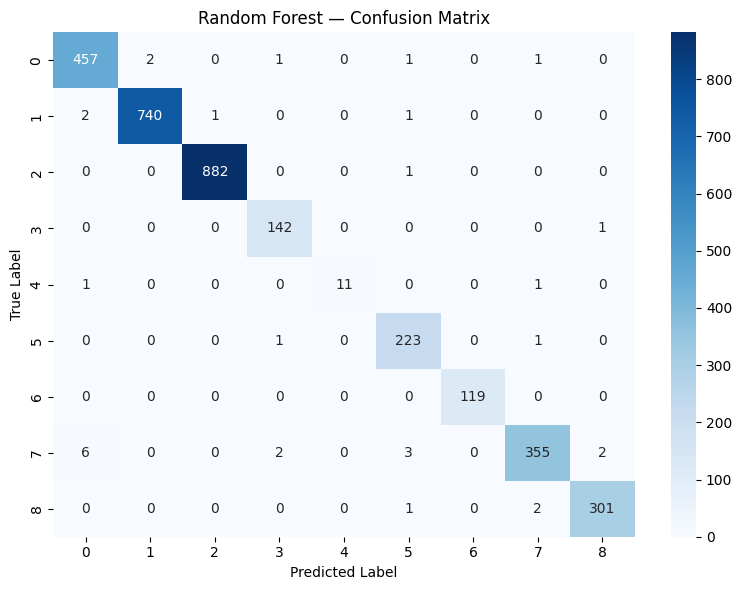

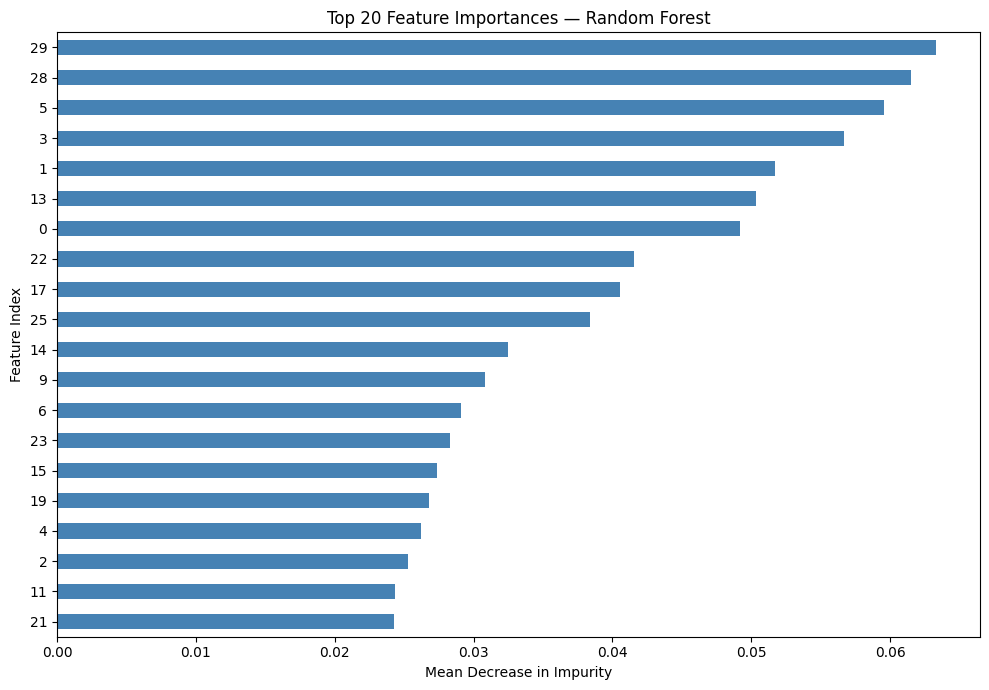

In [10]:
# ── 8. Confusion Matrix (Random Forest) ─────────────────────
rf_model = models['Random Forest']
cm = confusion_matrix(y_test, rf_model.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
# In Kaggle, files saved this way show up in the "Output" directory
plt.savefig('rf_confusion_matrix.png', dpi=150) 
plt.show()

# ── 9. Feature Importance (Random Forest) ───────────────────
# Since we converted to numpy arrays during RFE/Scaling, we use generic indices for feature names
feat_imp = pd.Series(rf_model.feature_importances_).nlargest(20)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Mean Decrease in Impurity')
plt.ylabel('Feature Index')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()